In [61]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np


Preview data

In [62]:
path = 'C:\\Users\\noname\\Documents\\Sales_report\\Sales\\'

In [63]:
dataframe = pd.read_csv(path + 'sales2019_2.csv')

In [64]:
dataframe.head(10)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,150502,iPhone,1,700,02/18/19 01:35,"866 Spruce St, Portland, ME 04101"
1,150503,AA Batteries (4-pack),1,3.84,02/13/19 07:24,"18 13th St, San Francisco, CA 94016"
2,150504,27in 4K Gaming Monitor,1,389.99,02/18/19 09:46,"52 6th St, New York City, NY 10001"
3,150505,Lightning Charging Cable,1,14.95,02/02/19 16:47,"129 Cherry St, Atlanta, GA 30301"
4,150506,AA Batteries (4-pack),2,3.84,02/28/19 20:32,"548 Lincoln St, Seattle, WA 98101"
5,150507,Lightning Charging Cable,1,14.95,02/24/19 18:50,"387 12th St, Austin, TX 73301"
6,150508,AA Batteries (4-pack),1,3.84,02/21/19 19:26,"622 Center St, San Francisco, CA 94016"
7,150509,Apple Airpods Headphones,1,150,02/26/19 19:53,"921 6th St, Seattle, WA 98101"
8,150510,USB-C Charging Cable,1,11.95,02/17/19 21:48,"451 2nd St, Los Angeles, CA 90001"
9,150511,USB-C Charging Cable,1,11.95,02/22/19 07:36,"689 River St, San Francisco, CA 94016"


In [65]:
frames  = []
all_length = []
for file in os.listdir(path):
    filepath = (path + file)  
    # print(filepath)
    df1 = pd.read_csv(filepath)
    frames.append(df1)
    result = pd.concat(frames)
    length1month = len(df1.index)
    all_length.append(length1month)
    
df = result    
df.to_csv("annualSales2019.csv", index= False)
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"
...,...,...,...,...,...,...
11681,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
11682,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
11683,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
11684,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"


In [66]:
print(sum(all_length))

186850


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186850 entries, 0 to 11685
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 10.0+ MB


Data Preprocessing

Drop Nan value

In [68]:
print(df.isnull().sum())


Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64


In [69]:
df = df.dropna(how='all')

Add "Month" Column

In [70]:
df["Month"] = df["Order Date"].str[0:2]

df.head()

C:\Users\noname\AppData\Local\Temp\ipykernel_1424\4114144137.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["Order Date"].str[0:2]


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",01
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",01
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",01
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",01
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",01


In [71]:
print(set(df['Month']))

{'11', '09', '02', '07', '08', '12', '06', '05', '04', '03', 'Or', '01', '10'}


Get rid of "Or" value

In [72]:
df = df[df['Month'] != 'Or']
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",01
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",01
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",01
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",01
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",01


Reporting

In [73]:
print(df['Quantity Ordered'].dtypes)
print(df['Price Each'].dtypes)

object
object


In [74]:
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], downcast= 'integer')
df['Price Each'] = pd.to_numeric(df['Price Each'], downcast= 'float')

In [75]:
df['Sales'] = df['Quantity Ordered'] * df['Price Each']
df.head()


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,141234,iPhone,1,700.000000,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",01,700.000000
1,141235,Lightning Charging Cable,1,14.950000,01/28/19 14:15,"185 Maple St, Portland, OR 97035",01,14.950000
2,141236,Wired Headphones,2,11.990000,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",01,23.980000
3,141237,27in FHD Monitor,1,149.990005,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",01,149.990005
4,141238,Wired Headphones,1,11.990000,01/25/19 11:59,"387 10th St, Austin, TX 73301",01,11.990000


In [76]:
move_column = df.pop('Sales')
df.insert(4 , 'Sales', move_column)
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Purchase Address,Month
0,141234,iPhone,1,700.000000,700.000000,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",01
1,141235,Lightning Charging Cable,1,14.950000,14.950000,01/28/19 14:15,"185 Maple St, Portland, OR 97035",01
2,141236,Wired Headphones,2,11.990000,23.980000,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",01
3,141237,27in FHD Monitor,1,149.990005,149.990005,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",01
4,141238,Wired Headphones,1,11.990000,11.990000,01/25/19 11:59,"387 10th St, Austin, TX 73301",01


 Doanh số theo tháng

In [77]:
sales_value = df.groupby('Month').sum()['Sales']

Text(0, 0.5, 'Sales in USD')

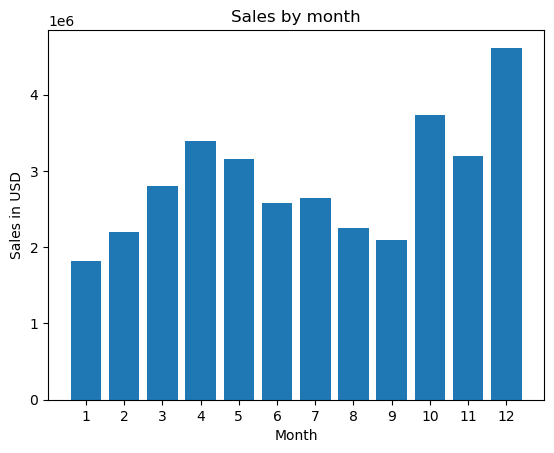

In [78]:
months = range(1,13)
plt.bar(x = months, height = sales_value)
plt.title('Sales by month')
plt.xticks(months)
plt.xlabel('Month')
plt.ylabel('Sales in USD')

 Doanh số theo thành phố

In [79]:
address_to_city = lambda address:address.split(',')[1]

In [80]:
df['City'] = df['Purchase Address'].apply(address_to_city)
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Purchase Address,Month,City
0,141234,iPhone,1,700.000000,700.000000,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",01,Boston
1,141235,Lightning Charging Cable,1,14.950000,14.950000,01/28/19 14:15,"185 Maple St, Portland, OR 97035",01,Portland
2,141236,Wired Headphones,2,11.990000,23.980000,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",01,San Francisco
3,141237,27in FHD Monitor,1,149.990005,149.990005,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",01,Los Angeles
4,141238,Wired Headphones,1,11.990000,11.990000,01/25/19 11:59,"387 10th St, Austin, TX 73301",01,Austin


In [81]:
df.groupby('City').sum()['Sales']

City
Atlanta          2795498.50
Austin           1819581.75
Boston           3661642.00
Dallas           2767975.50
Los Angeles      5452571.00
New York City    4664317.50
Portland         2320490.50
San Francisco    8262204.00
Seattle          2747755.50
Name: Sales, dtype: float32

In [82]:
sales_city = df.groupby('City').sum()['Sales']
sales_city.max()

8262204.0

In [83]:
cities =[]
for city, sales in sales_city.items():
    cities.append(city)
print(cities)

[' Atlanta', ' Austin', ' Boston', ' Dallas', ' Los Angeles', ' New York City', ' Portland', ' San Francisco', ' Seattle']


Text(0, 0.5, 'Sales in USD')

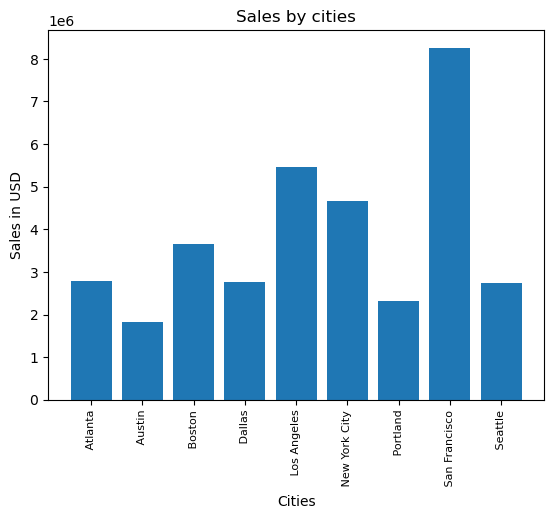

In [84]:
plt.bar(x = cities, height = sales_city)
plt.title('Sales by cities')
plt.xticks(cities, rotation = 90, size = 8  )
plt.xlabel('Cities')
plt.ylabel('Sales in USD')

In [85]:
print(df['Quantity Ordered'].dtypes)
print(df['Product'].dtypes)

int8
object


In [86]:
all_product = df.groupby('Product')['Quantity Ordered'].sum()
all_product

Product
20in Monitor                   4129
27in 4K Gaming Monitor         6244
27in FHD Monitor               7550
34in Ultrawide Monitor         6199
AA Batteries (4-pack)         27635
AAA Batteries (4-pack)        31017
Apple Airpods Headphones      15661
Bose SoundSport Headphones    13457
Flatscreen TV                  4819
Google Phone                   5532
LG Dryer                        646
LG Washing Machine              666
Lightning Charging Cable      23217
Macbook Pro Laptop             4728
ThinkPad Laptop                4130
USB-C Charging Cable          23975
Vareebadd Phone                2068
Wired Headphones              20557
iPhone                         6849
Name: Quantity Ordered, dtype: int64

Text(0, 0.5, 'Quanity')

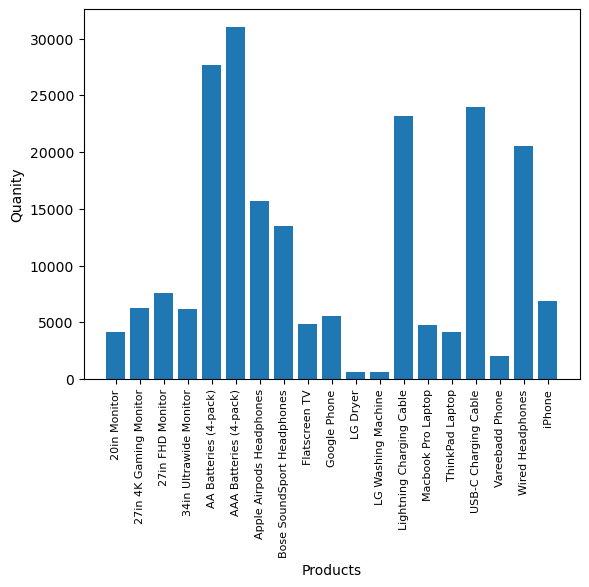

In [87]:
product_ls = [product for product, quant in all_product.items()]
plt.bar(x = product_ls, height = all_product)
plt.xticks(product_ls, rotation = 90, size = 8 )
plt.xlabel('Products')
plt.ylabel('Quanity')

In [88]:
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')


In [89]:
print(df['Price Each'].unique())

[ 700.     14.95   11.99  149.99    2.99  389.99   11.95   99.99  150.
 1700.    300.    400.      3.84  600.    109.99  379.99  999.99]


In [90]:
print(df['Price Each'].isna().sum())

0


In [91]:
print(df['Price Each'].dtypes)
print(df['Product'].dtypes)

float32
object


In [92]:
prices = df.groupby('Product')['Price Each'].mean()
prices


Product
20in Monitor                   109.989998
27in 4K Gaming Monitor         389.990021
27in FHD Monitor               149.990005
34in Ultrawide Monitor         379.990021
AA Batteries (4-pack)            3.840000
AAA Batteries (4-pack)           2.990000
Apple Airpods Headphones       150.000000
Bose SoundSport Headphones      99.989998
Flatscreen TV                  300.000000
Google Phone                   600.000000
LG Dryer                       600.000000
LG Washing Machine             600.000000
Lightning Charging Cable        14.950000
Macbook Pro Laptop            1700.000000
ThinkPad Laptop                999.989990
USB-C Charging Cable            11.950000
Vareebadd Phone                400.000000
Wired Headphones                11.990000
iPhone                         700.000000
Name: Price Each, dtype: float32

C:\Users\noname\AppData\Local\Temp\ipykernel_1424\1757348542.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(product_ls, rotation = 90, size = 8 )


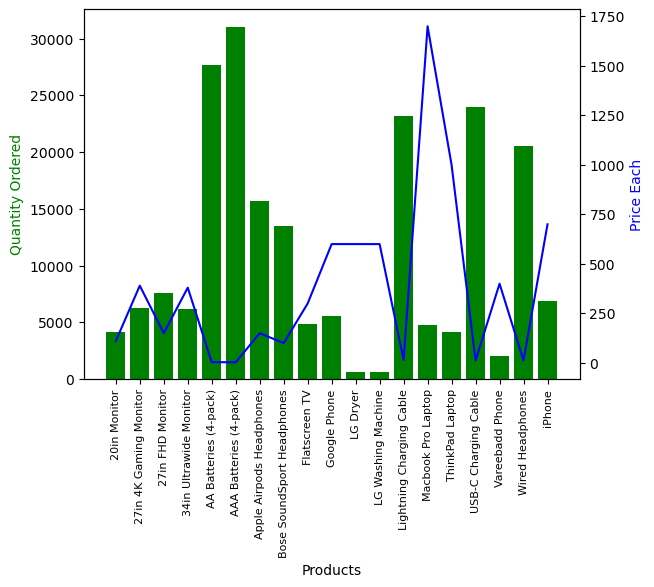

In [93]:
x = product_ls
y1 = all_product
y2 = prices

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.bar(x, y1, color='g')
ax2.plot(x, y2, 'b-')

ax1.set_xlabel('Products')
ax1.set_xticklabels(product_ls, rotation = 90, size = 8 )
ax1.set_ylabel('Quantity Ordered', color='g')
ax2.set_ylabel('Price Each', color='b')


plt.show()

In [94]:
df_dup = df[df['Order ID'].duplicated(keep=False)]
df_dup.head(10)

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Purchase Address,Month,City
41,141275,USB-C Charging Cable,1,11.950000,11.950000,01/07/19 16:06,"610 Walnut St, Austin, TX 73301",01,Austin
42,141275,Wired Headphones,1,11.990000,11.990000,01/07/19 16:06,"610 Walnut St, Austin, TX 73301",01,Austin
57,141290,Apple Airpods Headphones,1,150.000000,150.000000,01/02/19 08:25,"4 1st St, Los Angeles, CA 90001",01,Los Angeles
58,141290,AA Batteries (4-pack),3,3.840000,11.520000,01/02/19 08:25,"4 1st St, Los Angeles, CA 90001",01,Los Angeles
133,141365,Vareebadd Phone,1,400.000000,400.000000,01/10/19 11:19,"20 Dogwood St, New York City, NY 10001",01,New York City
134,141365,Wired Headphones,1,11.990000,11.990000,01/10/19 11:19,"20 Dogwood St, New York City, NY 10001",01,New York City
153,141384,Google Phone,1,600.000000,600.000000,01/03/19 00:14,"223 Jackson St, Boston, MA 02215",01,Boston
154,141384,USB-C Charging Cable,1,11.950000,11.950000,01/03/19 00:14,"223 Jackson St, Boston, MA 02215",01,Boston
220,141450,Google Phone,1,600.000000,600.000000,01/12/19 11:16,"521 Park St, San Francisco, CA 94016",01,San Francisco
221,141450,Bose SoundSport Headphones,1,99.989998,99.989998,01/12/19 11:16,"521 Park St, San Francisco, CA 94016",01,San Francisco


In [95]:
joinProduct = lambda product: ','.join(product)

In [96]:
df_dup['All Products'] = df_dup.groupby('Order ID')['Product'].transform(joinProduct)
df_dup.head()

C:\Users\noname\AppData\Local\Temp\ipykernel_1424\642342589.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dup['All Products'] = df_dup.groupby('Order ID')['Product'].transform(joinProduct)


,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Purchase Address,Month,City,All Products
41,141275,USB-C Charging Cable,1,11.95,11.95,01/07/19 16:06,"610 Walnut St, Austin, TX 73301",01,Austin,"USB-C Charging Cable,Wired Headphones"
42,141275,Wired Headphones,1,11.99,11.99,01/07/19 16:06,"610 Walnut St, Austin, TX 73301",01,Austin,"USB-C Charging Cable,Wired Headphones"
57,141290,Apple Airpods Headphones,1,150.00,150.00,01/02/19 08:25,"4 1st St, Los Angeles, CA 90001",01,Los Angeles,"Apple Airpods Headphones,AA Batteries (4-pack)"
58,141290,AA Batteries (4-pack),3,3.84,11.52,01/02/19 08:25,"4 1st St, Los Angeles, CA 90001",01,Los Angeles,"Apple Airpods Headphones,AA Batteries (4-pack)"
133,141365,Vareebadd Phone,1,400.00,400.00,01/10/19 11:19,"20 Dogwood St, New York City, NY 10001",01,New York City,"Vareebadd Phone,Wired Headphones"


In [97]:
df_dup = df_dup[['Order ID', 'All Products']].drop_duplicates()
df_dup.head()

,Order ID,All Products
41,141275,"USB-C Charging Cable,Wired Headphones"
57,141290,"Apple Airpods Headphones,AA Batteries (4-pack)"
133,141365,"Vareebadd Phone,Wired Headphones"
153,141384,"Google Phone,USB-C Charging Cable"
220,141450,"Google Phone,Bose SoundSport Headphones"


In [98]:
df_dup['All Products'].value_counts().head(10)

All Products
iPhone,Lightning Charging Cable                       882
Google Phone,USB-C Charging Cable                     856
iPhone,Wired Headphones                               361
Vareebadd Phone,USB-C Charging Cable                  312
Google Phone,Wired Headphones                         303
iPhone,Apple Airpods Headphones                       286
Google Phone,Bose SoundSport Headphones               161
Vareebadd Phone,Wired Headphones                      104
Google Phone,USB-C Charging Cable,Wired Headphones     77
Vareebadd Phone,Bose SoundSport Headphones             60
Name: count, dtype: int64

In [99]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

C:\Users\noname\AppData\Local\Temp\ipykernel_1424\3072535395.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])


In [100]:
print(df['Order Date'].dtypes)

datetime64[ns]


In [101]:
df["Hour"] = df['Order Date'].dt.hour
df

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Purchase Address,Month,City,Hour
0,141234,iPhone,1,700.000000,700.000000,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",01,Boston,21
1,141235,Lightning Charging Cable,1,14.950000,14.950000,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",01,Portland,14
2,141236,Wired Headphones,2,11.990000,23.980000,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",01,San Francisco,13
3,141237,27in FHD Monitor,1,149.990005,149.990005,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",01,Los Angeles,20
4,141238,Wired Headphones,1,11.990000,11.990000,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",01,Austin,11
...,...,...,...,...,...,...,...,...,...,...
11681,259353,AAA Batteries (4-pack),3,2.990000,8.970000,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",09,Los Angeles,20
11682,259354,iPhone,1,700.000000,700.000000,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",09,San Francisco,16
11683,259355,iPhone,1,700.000000,700.000000,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",09,San Francisco,7
11684,259356,34in Ultrawide Monitor,1,379.989990,379.989990,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",09,San Francisco,17


In [102]:
sales_value_hour= df.groupby(['Hour'])['Sales'].count()

Text(0, 0.5, 'Quantity')

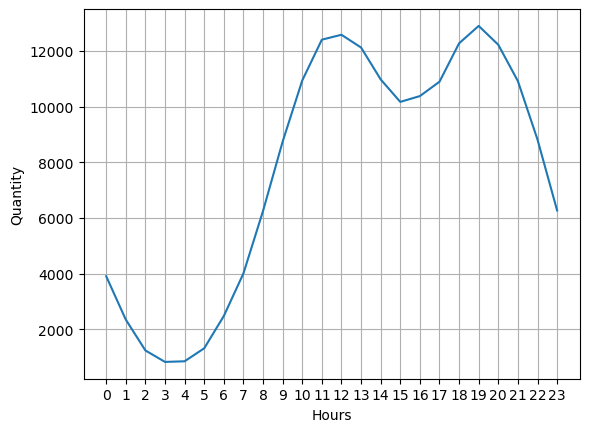

In [103]:
hour = [hour for hour,sales in sales_value_hour.items()]
plt.plot( hour , sales_value_hour )
plt.grid()
plt.xticks(hour)
plt.xlabel('Hours')
plt.ylabel('Quantity')

XGBoost Model

In [104]:
df

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Purchase Address,Month,City,Hour
0,141234,iPhone,1,700.000000,700.000000,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",01,Boston,21
1,141235,Lightning Charging Cable,1,14.950000,14.950000,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",01,Portland,14
2,141236,Wired Headphones,2,11.990000,23.980000,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",01,San Francisco,13
3,141237,27in FHD Monitor,1,149.990005,149.990005,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",01,Los Angeles,20
4,141238,Wired Headphones,1,11.990000,11.990000,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",01,Austin,11
...,...,...,...,...,...,...,...,...,...,...
11681,259353,AAA Batteries (4-pack),3,2.990000,8.970000,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",09,Los Angeles,20
11682,259354,iPhone,1,700.000000,700.000000,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",09,San Francisco,16
11683,259355,iPhone,1,700.000000,700.000000,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",09,San Francisco,7
11684,259356,34in Ultrawide Monitor,1,379.989990,379.989990,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",09,San Francisco,17


In [105]:
df['Month'] = df['Month'].astype(int)

In [106]:
le_product = LabelEncoder()
le_city = LabelEncoder()

df['Product_ec'] = le_product.fit_transform(df['Product'])
df['City_ec'] = le_city.fit_transform(df['City'])


In [107]:
df.reset_index(drop=True, inplace=True)


In [108]:
df

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Purchase Address,Month,City,Hour,Product_ec,City_ec
0,141234,iPhone,1,700.000000,700.000000,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",1,Boston,21,18,2
1,141235,Lightning Charging Cable,1,14.950000,14.950000,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",1,Portland,14,12,6
2,141236,Wired Headphones,2,11.990000,23.980000,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",1,San Francisco,13,17,7
3,141237,27in FHD Monitor,1,149.990005,149.990005,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",1,Los Angeles,20,2,4
4,141238,Wired Headphones,1,11.990000,11.990000,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",1,Austin,11,17,1
...,...,...,...,...,...,...,...,...,...,...,...,...
185945,259353,AAA Batteries (4-pack),3,2.990000,8.970000,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",9,Los Angeles,20,5,4
185946,259354,iPhone,1,700.000000,700.000000,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",9,San Francisco,16,18,7
185947,259355,iPhone,1,700.000000,700.000000,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",9,San Francisco,7,18,7
185948,259356,34in Ultrawide Monitor,1,379.989990,379.989990,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",9,San Francisco,17,3,7


In [109]:
train_data = df[df['Month'].isin([1, 2, 3, 4, 5, 6, 7, 8, 9])]
test_data = df[df['Month'].isin([10, 11, 12])]


In [114]:
X_train =  train_data.drop(columns=['Sales', 'Order ID', 'Order Date', 'Purchase Address', 'City', 'Product'])
y_train = train_data['Sales']

X_test = test_data.drop(columns=['Sales', 'Order ID','Order Date', 'Purchase Address', 'City', 'Product'])
y_test = test_data['Sales']

In [115]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split



# Khởi tạo và huấn luyện
model = XGBRegressor( n_estimators=1000,
                    learning_rate=0.1,
                    early_stopping_rounds=50,  # chỉ có tác dụng khi eval_set được cung cấp
                    eval_metric='rmse')
model.fit( X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True)



[0]	validation_0-rmse:299.22201
[1]	validation_0-rmse:269.31986
[2]	validation_0-rmse:242.40747
[3]	validation_0-rmse:218.18603
[4]	validation_0-rmse:196.38667
[5]	validation_0-rmse:176.76724
[6]	validation_0-rmse:159.11004
[7]	validation_0-rmse:143.21630
[8]	validation_0-rmse:128.91141
[9]	validation_0-rmse:116.03651
[10]	validation_0-rmse:104.44866
[11]	validation_0-rmse:94.01918
[12]	validation_0-rmse:84.63218
[13]	validation_0-rmse:76.18373
[14]	validation_0-rmse:68.57982
[15]	validation_0-rmse:61.73615
[16]	validation_0-rmse:55.57646
[17]	validation_0-rmse:50.03269
[18]	validation_0-rmse:45.04315
[19]	validation_0-rmse:40.55254
[20]	validation_0-rmse:36.51076
[21]	validation_0-rmse:32.87318
[22]	validation_0-rmse:29.59938
[23]	validation_0-rmse:26.65299
[24]	validation_0-rmse:24.00126
[25]	validation_0-rmse:21.61468
[26]	validation_0-rmse:19.46690
[27]	validation_0-rmse:17.53409
[28]	validation_0-rmse:15.79453
[29]	validation_0-rmse:14.22924
[30]	validation_0-rmse:12.82057
[31]	va

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [116]:
y_pred = model.predict(X_test)


In [117]:
y_pred

array([379.9899   , 389.98987  ,   5.9802127, ...,   8.969381 ,
        99.98995  ,   3.8400962], dtype=float32)

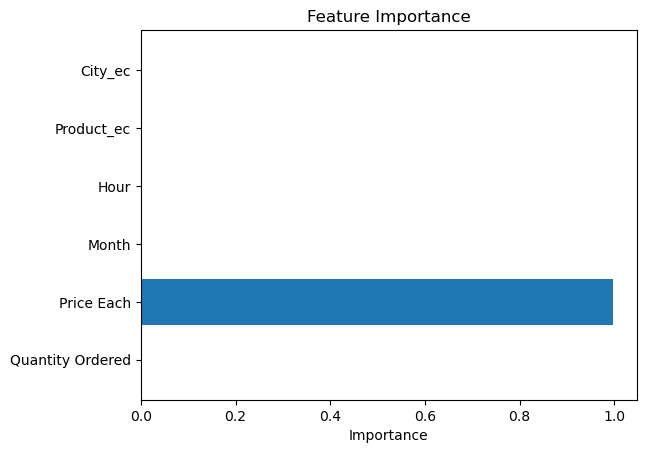

In [118]:
importances = model.feature_importances_

# Sắp xếp và vẽ biểu đồ các đặc trưng quan trọng
plt.barh(X_train.columns, importances)
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

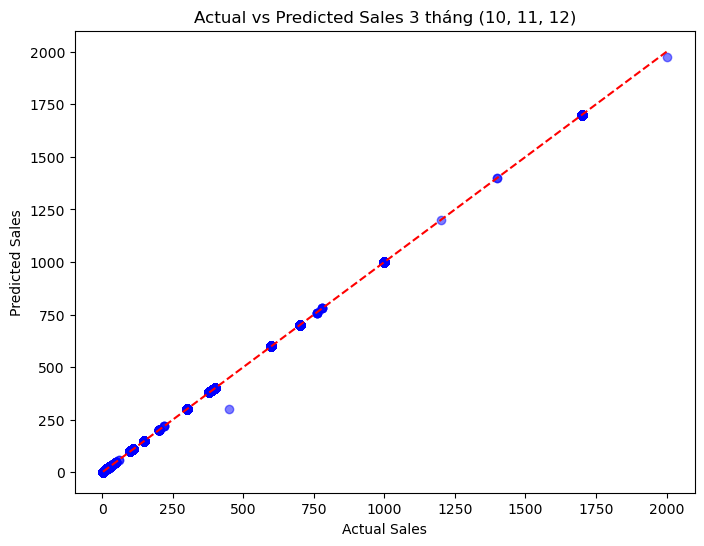

In [119]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales 3 tháng (10, 11, 12)')
plt.show()
